In [ ]:
import numpy as np

import torch
import torch.nn as nn
from torch.autograd import Variable

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
M = 32
p = 4

activation_1 = nn.SiLU()

class Net2D(nn.Module):
    def __init__(self):
        super(Net2D, self).__init__()
        torch.manual_seed(7)
        self.hidden_layer1 = nn.Linear(3, M)
        self.hidden_layer2 = nn.Linear(M, M)
        self.hidden_layer3 = nn.Linear(M, M)
        self.hidden_layer4 = nn.Linear(M, M)
        self.output_layer = nn.Linear(M, 1)
        #self.gelu = nn.GELU()

    def forward(self, x, y, r):
        inputs = torch.cat([x, y, r], dim=1)
        layer1_out = activation_1(self.hidden_layer1(inputs))
        layer2_out = activation_1(self.hidden_layer2(layer1_out))
        layer3_out = activation_1(self.hidden_layer3(layer2_out))
        layer4_out = activation_1(self.hidden_layer4(layer3_out))
        output = self.output_layer(layer4_out)

        return output

net_pinn = Net2D()
net_pinn = net_pinn.to(device)
optimizer1 = torch.optim.Adam(net_pinn.parameters(), lr = 0.001)

In [ ]:
net_drm = Net2D()
net_drm = net_drm.to(device)
optimizer2 = torch.optim.Adam(net_drm.parameters(), lr = 0.001)

In [ ]:
net_mix = Net2D()
net_mix = net_mix.to(device)
optimizer3 = torch.optim.Adam(net_mix.parameters(), lr = 0.001)

In [ ]:
#True solution : u = r**2 - x**2 - y**2

def PINN_f(x, y, r, net):

    global p

    u = (r**2 - x**2 - y**2) * net(x, y, r)

    u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x.sum(), x, create_graph=True)[0]
    u_xy = torch.autograd.grad(u_x.sum(), y, create_graph=True)[0]
    u_y = torch.autograd.grad(u.sum(), y, create_graph=True)[0]
    u_yx = torch.autograd.grad(u_y.sum(), x, create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y.sum(), y, create_graph=True)[0]

    f = 4*(4*x**2 + 4*y**2)**((p-2)/2) + 8*(p - 2)*(x**2 + y**2)*(4*x**2 + 4*y**2)**((p-4)/2)

    loss = torch.mean((u_xx + u_yy)*(u_x**2 + u_y**2)**((p-2)/2) + 2*(u_x*(u_x*u_xx + u_y*u_yx) + u_y*(u_y*u_yy + u_x*u_xy))*(u_x**2 + u_y**2)**((p-4)/2) + f)**2

    #loss = torch.mean(div(x, y, ((u_x**2 + u_y**2)**((p-2)/2))*u_x, ((u_x**2 + u_y**2)**((p-2)/2))*u_y) + f)

    return loss

In [ ]:
#Sampling for circle domain

# 장치 설정 (예: 'cpu' 또는 'cuda')
#device = 'cpu'

# 파라미터 설정
ob_r = np.random.uniform(1, 6, 100)
num_points = 40  # 그리드 해상도 (각 축당 포인트 개수)
#epsilon = 0.05

x_collocation = []
y_collocation = []
r_collocation = []

for r in ob_r:
    x = np.linspace(-r, r, num_points)
    y = np.linspace(-r, r, num_points)

    X, Y = np.meshgrid(x, y)

    mask = X**2 + Y**2 <= r**2
    X_inside = X[mask]
    Y_inside = Y[mask]

    # 리스트에 저장
    x_collocation.append(X_inside)
    y_collocation.append(Y_inside)
    r_collocation.append(np.full_like(X_inside, r))

# 리스트를 펼쳐서 PyTorch 텐서로 변환
x_collocation = np.concatenate(x_collocation).reshape(-1, 1)
y_collocation = np.concatenate(y_collocation).reshape(-1, 1)
r_collocation = np.concatenate(r_collocation).reshape(-1, 1)

pt_x = Variable(torch.from_numpy(x_collocation).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_collocation).float(), requires_grad=True).to(device)
pt_r = Variable(torch.from_numpy(r_collocation).float(), requires_grad=True).to(device)


iterations = 5000


# **PINN**

In [ ]:
error_list1 = []  # for PINN error graph
loss_list1 = []

for epoch in range(iterations+1):
    optimizer1.zero_grad()  # to make the gradients zero

    f_PINN = PINN_f(pt_x, pt_y, pt_r, net_pinn)

    f_PINN.backward()
    optimizer1.step()

    if epoch % 50 == 0:
        pt_u = (pt_r**2 - pt_x**2 - pt_y**2) * net_pinn(pt_x, pt_y, pt_r)

        solution = pt_r**2 - pt_x**2 - pt_y**2
        error1 = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch:", epoch)
        print("PINN_loss:", f_PINN.item())
        print("relative L2 error:", error1)
        print("---------------------------------------------------")

        loss_list1.append(f_PINN.item())
        error_list1.append(error1.item())

Epoch: 0
PINN_loss: 48300.1640625
relative L2 error: tensor(0.8886, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch: 50
PINN_loss: 1204.156494140625
relative L2 error: tensor(0.1538, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch: 100
PINN_loss: 4.220088005065918
relative L2 error: tensor(0.1521, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch: 150
PINN_loss: 0.009725510142743587
relative L2 error: tensor(0.1526, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch: 200
PINN_loss: 5.381461960496381e-06
relative L2 error: tensor(0.1526, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch: 250
PINN_loss: 5.482009441948321e-07
relative L2 error: tensor(0.1526, device='cuda:0', grad_fn=<PowBackward0>)
----------------------------------------------

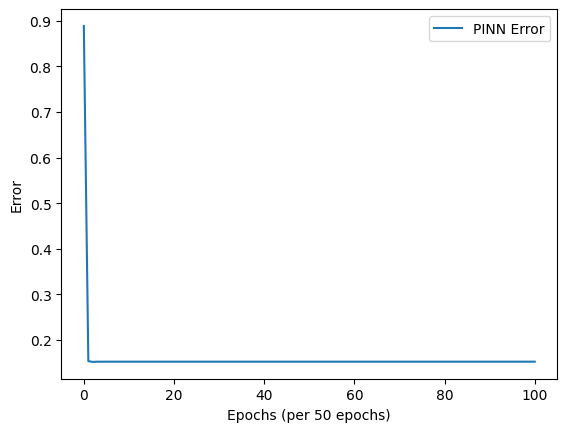

In [ ]:
import matplotlib.pyplot as plt
# 손실 값 리스트를 이용하여 그래프 그리기

plt.plot(error_list1, label='PINN Error')

# 그래프에 제목, 축 레이블 추가
#plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

# 범례 추가
plt.legend()

# 그래프 보여주기
plt.show()


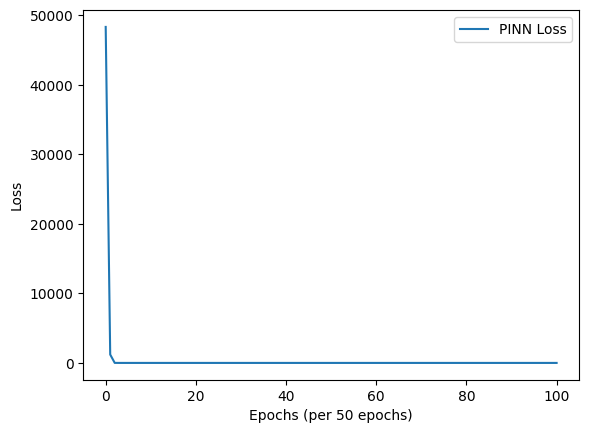

In [ ]:
plt.plot(loss_list1, label='PINN Loss')

# 그래프에 제목, 축 레이블 추가
#plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

# 범례 추가
plt.legend()

# 그래프 보여주기
plt.show()

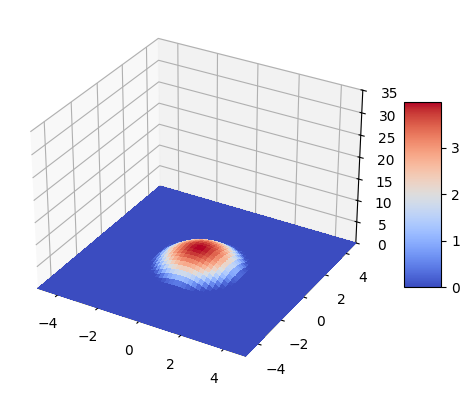

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

# 3D 플롯 초기화
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

r = 2

# -r에서 r까지 균일한 포인트 생성
ob_x = np.linspace(-5, 5, 200)
ob_y = np.linspace(-5, 5, 200)

# 메쉬 그리드 생성
x_array, y_array = np.meshgrid(ob_x, ob_y)

# 원 안의 점들 마스크 생성
mask = x_array**2 + y_array**2 <= r**2
X_inside = x_array[mask]
Y_inside = y_array[mask]
R = np.full_like(X_inside, r)

# 텐서로 변환
x1 = np.ravel(X_inside).reshape(-1, 1)
y1 = np.ravel(Y_inside).reshape(-1, 1)
r1 = np.ravel(R).reshape(-1, 1)


g_x = Variable(torch.from_numpy(x1).float(), requires_grad=True).to(device)
g_y = Variable(torch.from_numpy(y1).float(), requires_grad=True).to(device)
g_r = Variable(torch.from_numpy(r1).float(), requires_grad=True).to(device)

# 신경망 예측
#Predict = (g_r**2 - g_x**2 - g_y**2) * net_pinn(g_x, g_y, g_r)
#Predict = (g_r**2 - g_x**2 - g_y**2) * (1 - net_pinn(g_x, g_y, g_r))
Predict = (g_r**2 - g_x**2 - g_y**2)

# 3D 그래프를 위한 Z값 계산
Z = np.zeros_like(x_array)  # Z값을 0으로 초기화
Z[mask] = Predict.data.cpu().numpy().reshape(X_inside.shape)  # 원 안의 값만 업데이트

# 3D 표면 플롯
surf = ax.plot_surface(x_array, y_array, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)

# 색상 바 추가
fig.colorbar(surf, shrink=0.5, aspect=5)

# z축 범위 및 눈금 설정
ax.set_zlim(0.00, 35)  # z축의 값 범위를 설정
ax.set_ylim(-5, 5)
ax.set_xlim(-5, 5)


#plt.title('3D Surface Plot Inside Circle   (PINN, r = 3)')

plt.show()


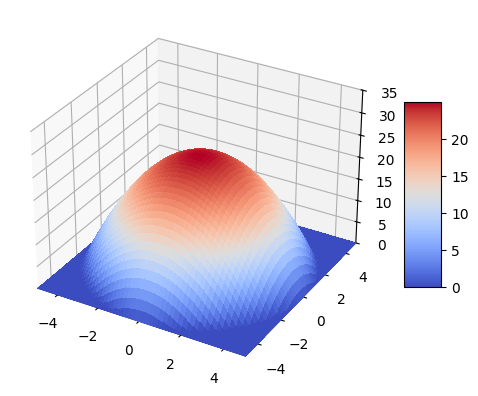

In [ ]:
#True solution

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

# 3D 플롯 초기화
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

r = 5

# -r에서 r까지 균일한 포인트 생성
ob_x = np.linspace(-5, 5, 200)
ob_y = np.linspace(-5, 5, 200)

# 메쉬 그리드 생성
x_array, y_array = np.meshgrid(ob_x, ob_y)

# 원 안의 점들 마스크 생성
mask = x_array**2 + y_array**2 <= r**2
X_inside = x_array[mask]
Y_inside = y_array[mask]
R = np.full_like(X_inside, r)

# 텐서로 변환
x1 = np.ravel(X_inside).reshape(-1, 1)
y1 = np.ravel(Y_inside).reshape(-1, 1)
r1 = np.ravel(R).reshape(-1, 1)


g_x = Variable(torch.from_numpy(x1).float(), requires_grad=True).to(device)
g_y = Variable(torch.from_numpy(y1).float(), requires_grad=True).to(device)
g_r = Variable(torch.from_numpy(r1).float(), requires_grad=True).to(device)

# 신경망 예측
Solution = g_r**2 - g_x**2 - g_y**2

# 3D 그래프를 위한 Z값 계산
Z = np.zeros_like(x_array)  # Z값을 0으로 초기화
Z[mask] = Solution.data.cpu().numpy().reshape(X_inside.shape)  # 원 안의 값만 업데이트

# 3D 표면 플롯
surf = ax.plot_surface(x_array, y_array, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)

# 색상 바 추가
fig.colorbar(surf, shrink=0.5, aspect=5)

# z축 범위 및 눈금 설정
ax.set_zlim(0.00, 35)  # z축의 값 범위를 설정
ax.set_ylim(-5, 5)
ax.set_xlim(-5, 5)


#plt.title('3D Surface Plot Inside Circle   (True Solution, r = 1)')
#plt.xlabel('X-axis')
#plt.ylabel('Y-axis')

plt.show()


# **DeepRitzMethod**

In [ ]:
#True solution : u = r**2 - x**2 - y**2

def DRM_f(x, y, r, net):

    global p

    u = (r**2 - x**2 - y**2) * net(x, y, r)

    u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_y = torch.autograd.grad(u.sum(), y, create_graph=True)[0]

    f = 4*(4*x**2 + 4*y**2)**((p-2)/2) + 8*(p - 2)*(x**2 + y**2)*(4*x**2 + 4*y**2)**((p-4)/2)

    loss = torch.mean((1/p)*((u_x)**2 + (u_y)**2)**(p/2) - f*u)

    return loss

In [ ]:
#Sampling for circle domain

# 장치 설정 (예: 'cpu' 또는 'cuda')
#device = 'cpu'

# 파라미터 설정
ob_r = np.random.uniform(1, 6, 100)
num_points = 40  # 그리드 해상도 (각 축당 포인트 개수)
#epsilon = 0.05

x_collocation = []
y_collocation = []
r_collocation = []

for r in ob_r:
    x = np.linspace(-r, r, num_points)
    y = np.linspace(-r, r, num_points)

    X, Y = np.meshgrid(x, y)

    mask = X**2 + Y**2 <= r**2
    X_inside = X[mask]
    Y_inside = Y[mask]

    # 리스트에 저장
    x_collocation.append(X_inside)
    y_collocation.append(Y_inside)
    r_collocation.append(np.full_like(X_inside, r))

# 리스트를 펼쳐서 PyTorch 텐서로 변환
x_collocation = np.concatenate(x_collocation).reshape(-1, 1)
y_collocation = np.concatenate(y_collocation).reshape(-1, 1)
r_collocation = np.concatenate(r_collocation).reshape(-1, 1)

pt_x = Variable(torch.from_numpy(x_collocation).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_collocation).float(), requires_grad=True).to(device)
pt_r = Variable(torch.from_numpy(r_collocation).float(), requires_grad=True).to(device)


iterations = 5000


In [ ]:
error_list2 = []  # for DRM error graph
loss_list2 = []

for epoch in range(iterations+1):
    optimizer2.zero_grad()  # to make the gradients zero

    f_energy = DRM_f(pt_x, pt_y, pt_r, net_drm)

    f_energy.backward()
    optimizer2.step()

    if epoch % 50 == 0:
        pt_u = (pt_r**2-pt_x**2-pt_y**2) * net_drm(pt_x, pt_y, pt_r)

        solution = pt_r**2-pt_x**2-pt_y**2
        error1 = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch:", epoch)
        print("DRM_loss:", f_energy.item())
        print("relative L2 error:", error1.item())
        print("---------------------------------------------------")

        loss_list2.append(f_energy.item())
        error_list2.append(error1.item())

Epoch: 0
DRM_loss: -169.85479736328125
relative L2 error: 0.8877785205841064
---------------------------------------------------
Epoch: 50
DRM_loss: -1290.5989990234375
relative L2 error: 0.12191387265920639
---------------------------------------------------
Epoch: 100
DRM_loss: -1314.5062255859375
relative L2 error: 0.07344315946102142
---------------------------------------------------
Epoch: 150
DRM_loss: -1323.6885986328125
relative L2 error: 0.04152419790625572
---------------------------------------------------
Epoch: 200
DRM_loss: -1327.361083984375
relative L2 error: 0.019342247396707535
---------------------------------------------------
Epoch: 250
DRM_loss: -1328.08837890625
relative L2 error: 0.013464280404150486
---------------------------------------------------
Epoch: 300
DRM_loss: -1328.2421875
relative L2 error: 0.012767074629664421
---------------------------------------------------
Epoch: 350
DRM_loss: -1328.3167724609375
relative L2 error: 0.012310279533267021
-----

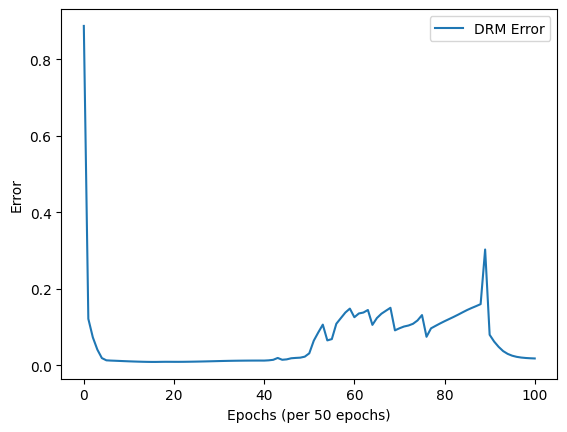

In [ ]:
plt.plot(error_list2, label='DRM Error')

#plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()

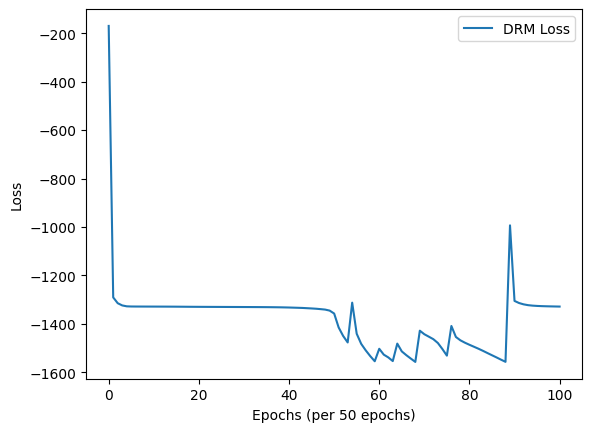

In [ ]:
plt.plot(loss_list2, label='DRM Loss')

#plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

plt.legend()

plt.show()

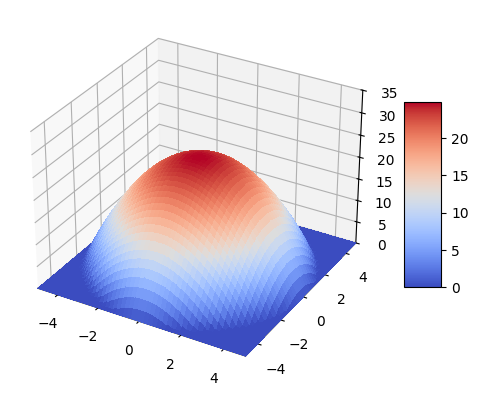

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

# 3D 플롯 초기화
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

r = 5

# -r에서 r까지 균일한 포인트 생성
ob_x = np.linspace(-5, 5, 200)
ob_y = np.linspace(-5, 5, 200)

# 메쉬 그리드 생성
x_array, y_array = np.meshgrid(ob_x, ob_y)

# 원 안의 점들 마스크 생성
mask = x_array**2 + y_array**2 <= r**2
X_inside = x_array[mask]
Y_inside = y_array[mask]
R = np.full_like(X_inside, r)

# 텐서로 변환
x1 = np.ravel(X_inside).reshape(-1, 1)
y1 = np.ravel(Y_inside).reshape(-1, 1)
r1 = np.ravel(R).reshape(-1, 1)

# GPU를 사용할 경우 device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

g_x = Variable(torch.from_numpy(x1).float(), requires_grad=True).to(device)
g_y = Variable(torch.from_numpy(y1).float(), requires_grad=True).to(device)
g_r = Variable(torch.from_numpy(r1).float(), requires_grad=True).to(device)

# 신경망 예측
Predict = (g_r**2 - g_x**2 - g_y**2) * net_drm(g_x, g_y, g_r)
#Predict = (g_r**2 - g_x**2 - g_y**2) * (1 - net_drm(g_x, g_y, g_r))

# 3D 그래프를 위한 Z값 계산
Z = np.zeros_like(x_array)  # Z값을 0으로 초기화
Z[mask] = Predict.data.cpu().numpy().reshape(X_inside.shape)  # 원 안의 값만 업데이트

# 3D 표면 플롯
surf = ax.plot_surface(x_array, y_array, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)

# 색상 바 추가
fig.colorbar(surf, shrink=0.5, aspect=5)

# z축 범위 및 눈금 설정
ax.set_zlim(0.00, 35)  # z축의 값 범위를 설정
ax.set_ylim(-5, 5)
ax.set_xlim(-5, 5)

#plt.title('3D Surface Plot Inside Circle   (DRM, r = 5)')
#plt.xlabel('X-axis')
#plt.ylabel('Y-axis')

plt.show()


# PINN + **DeepRitzMethod**

In [ ]:
#True solution : u = r**2 - x**2 - y**2

def mix_f(x, y, r, net):

  global p

  u = (r**2 - x**2 - y**2) * net(x, y, r)

  u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
  u_xx = torch.autograd.grad(u_x.sum(), x, create_graph=True)[0]
  u_xy = torch.autograd.grad(u_x.sum(), y, create_graph=True)[0]
  u_y = torch.autograd.grad(u.sum(), y, create_graph=True)[0]
  u_yx = torch.autograd.grad(u_y.sum(), x, create_graph=True)[0]
  u_yy = torch.autograd.grad(u_y.sum(), y, create_graph=True)[0]


  f = 4*(4*x**2 + 4*y**2)**((p-2)/2) + 8*(p - 2)*(x**2 + y**2)*(4*x**2 + 4*y**2)**((p-4)/2)

  loss1 = torch.mean((u_xx + u_yy)*(u_x**2 + u_y**2)**((p-2)/2) + 2*(u_x*(u_x*u_xx + u_y*u_yx) + u_y*(u_y*u_yy + u_x*u_xy))*(u_x**2 + u_y**2)**((p-4)/2) + f)**2
  loss2 = torch.mean(((u_x)**2 + (u_y)**2)**(p/2)/p - f*u)

  loss = 0.3*loss1 + 0.7*loss2

  return loss

In [ ]:
#Sampling for circle domain

# 장치 설정 (예: 'cpu' 또는 'cuda')
#device = 'cpu'

# 파라미터 설정
ob_r = np.random.uniform(1, 6, 100)
num_points = 40  # 그리드 해상도 (각 축당 포인트 개수)
#epsilon = 0.05

x_collocation = []
y_collocation = []
r_collocation = []

for r in ob_r:
    x = np.linspace(-r, r, num_points)
    y = np.linspace(-r, r, num_points)

    X, Y = np.meshgrid(x, y)

    mask = X**2 + Y**2 <= r**2
    X_inside = X[mask]
    Y_inside = Y[mask]

    # 리스트에 저장
    x_collocation.append(X_inside)
    y_collocation.append(Y_inside)
    r_collocation.append(np.full_like(X_inside, r))

# 리스트를 펼쳐서 PyTorch 텐서로 변환
x_collocation = np.concatenate(x_collocation).reshape(-1, 1)
y_collocation = np.concatenate(y_collocation).reshape(-1, 1)
r_collocation = np.concatenate(r_collocation).reshape(-1, 1)

pt_x = Variable(torch.from_numpy(x_collocation).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_collocation).float(), requires_grad=True).to(device)
pt_r = Variable(torch.from_numpy(r_collocation).float(), requires_grad=True).to(device)


iterations = 5000


In [ ]:
error_list3 = []  # for Mix error graph
loss_list3 = []

for epoch in range(iterations+1):
    optimizer3.zero_grad()  # to make the gradients zero

    f_mix = mix_f(pt_x, pt_y, pt_r, net_mix)

    f_mix.backward()
    optimizer3.step()

    if epoch % 50 == 0:
        pt_u = (pt_r**2-pt_x**2-pt_y**2) * net_mix(pt_x, pt_y, pt_r)

        solution = pt_r**2-pt_x**2-pt_y**2
        error1 = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch:", epoch)
        print("Mix_loss:", f_mix.item())
        print("relative L2 error:", error1.item())
        print("---------------------------------------------------")

        loss_list3.append(f_mix.item())
        error_list3.append(error1.item())

Epoch: 0
Mix_loss: 18360.400390625
relative L2 error: 0.8886348009109497
---------------------------------------------------
Epoch: 50
Mix_loss: -498.7635498046875
relative L2 error: 0.15109001100063324
---------------------------------------------------
Epoch: 100
Mix_loss: -947.8085327148438
relative L2 error: 0.1449129432439804
---------------------------------------------------
Epoch: 150
Mix_loss: -953.2868041992188
relative L2 error: 0.13983452320098877
---------------------------------------------------
Epoch: 200
Mix_loss: -956.7623901367188
relative L2 error: 0.13438086211681366
---------------------------------------------------
Epoch: 250
Mix_loss: -959.7098999023438
relative L2 error: 0.12918159365653992
---------------------------------------------------
Epoch: 300
Mix_loss: -962.238037109375
relative L2 error: 0.12422558665275574
---------------------------------------------------
Epoch: 350
Mix_loss: -964.4779663085938
relative L2 error: 0.11943462491035461
-------------

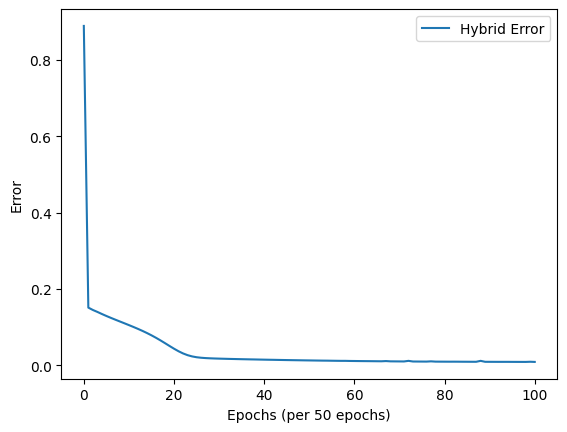

In [ ]:
plt.plot(error_list3, label='Hybrid Error')

# 그래프에 제목, 축 레이블 추가
#plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

# 범례 추가
plt.legend()

# 그래프 보여주기
plt.show()

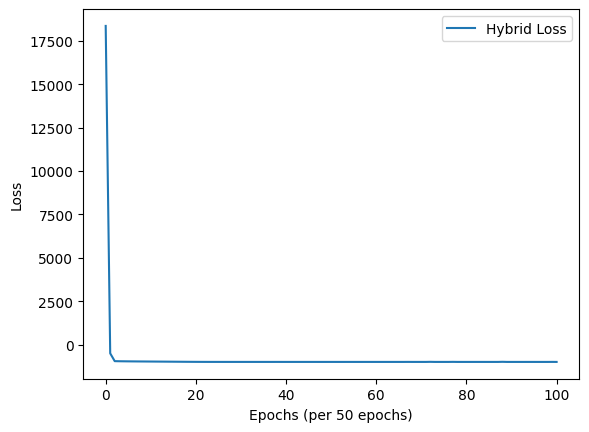

In [ ]:
plt.plot(loss_list3, label='Hybrid Loss')

# 그래프에 제목, 축 레이블 추가
#plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

# 범례 추가
plt.legend()

# 그래프 보여주기
plt.show()

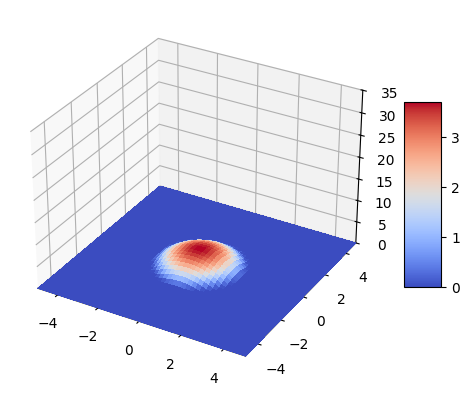

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

# 3D 플롯 초기화
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

r = 2

# -r에서 r까지 균일한 포인트 생성
ob_x = np.linspace(-5, 5, 200)
ob_y = np.linspace(-5, 5, 200)

# 메쉬 그리드 생성
x_array, y_array = np.meshgrid(ob_x, ob_y)

# 원 안의 점들 마스크 생성
mask = x_array**2 + y_array**2 <= r**2
X_inside = x_array[mask]
Y_inside = y_array[mask]
R = np.full_like(X_inside, r)

# 텐서로 변환
x1 = np.ravel(X_inside).reshape(-1, 1)
y1 = np.ravel(Y_inside).reshape(-1, 1)
r1 = np.ravel(R).reshape(-1, 1)

# GPU를 사용할 경우 device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

g_x = Variable(torch.from_numpy(x1).float(), requires_grad=True).to(device)
g_y = Variable(torch.from_numpy(y1).float(), requires_grad=True).to(device)
g_r = Variable(torch.from_numpy(r1).float(), requires_grad=True).to(device)

# 신경망 예측
Predict = (g_r**2 - g_x**2 - g_y**2) * net_mix(g_x, g_y, g_r)
#Predict = (g_r**2 - g_x**2 - g_y**2) * (1 - net_mix(g_x, g_y, g_r))

# 3D 그래프를 위한 Z값 계산
Z = np.zeros_like(x_array)  # Z값을 0으로 초기화
Z[mask] = Predict.data.cpu().numpy().reshape(X_inside.shape)  # 원 안의 값만 업데이트

# 3D 표면 플롯
surf = ax.plot_surface(x_array, y_array, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)

# 색상 바 추가
fig.colorbar(surf, shrink=0.5, aspect=5)

# z축 범위 및 눈금 설정
ax.set_zlim(0, 35)  # z축의 값 범위를 설정
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

#plt.title('3D Surface Plot Inside Circle   (Mix, r = 1)')
#plt.xlabel('X-axis')
#plt.ylabel('Y-axis')

plt.show()

# **Learning Curve**

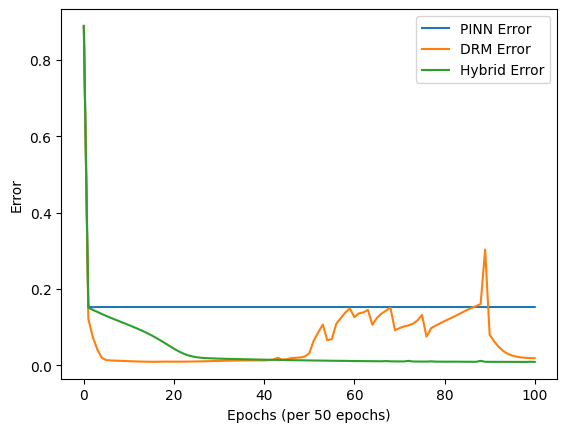

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_list1, label='PINN Error')
plt.plot(error_list2, label='DRM Error')
plt.plot(error_list3, label='Hybrid Error')

#plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

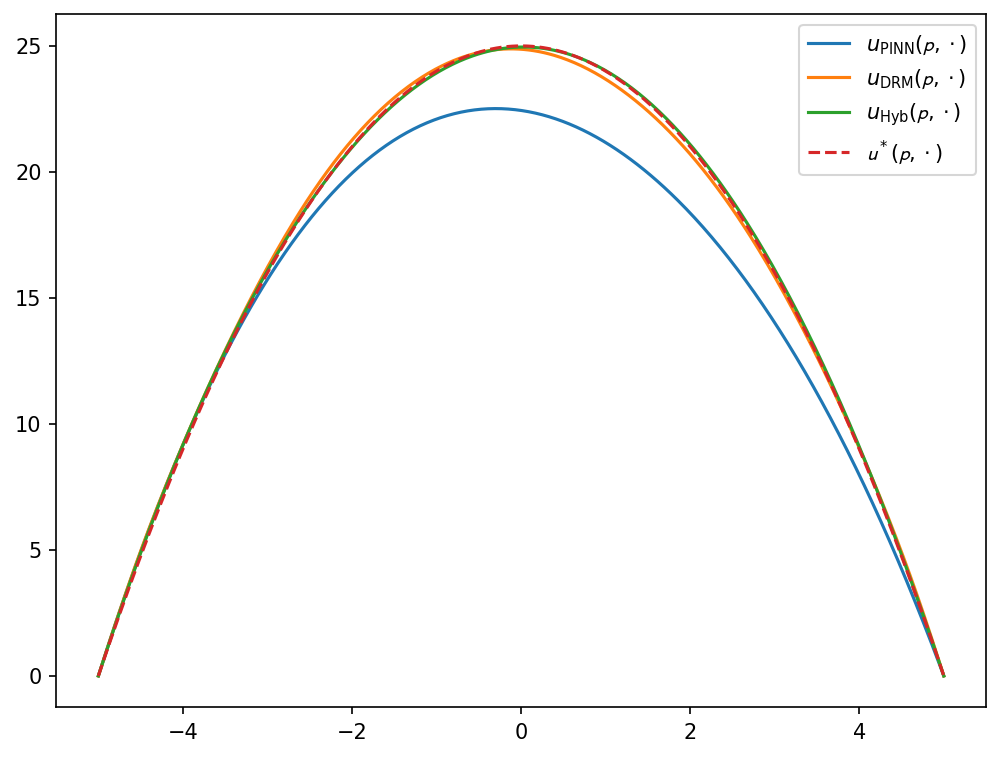

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()

Nr=5

y_np = np.linspace(-Nr, Nr, 500)
r_np = Nr*np.ones_like(y_np)
x_np = np.zeros_like(y_np)


x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
r = Variable(torch.from_numpy(r_np).float().unsqueeze(1), requires_grad=True).to(device)


# f(x, y) 계산
z_True = r**2 - x**2 - y**2
z_True = z_True.cpu().detach().numpy()
z_PINN = ((r**2 - x**2 - y**2)*net_pinn(x, y, r)).cpu().detach().numpy()
z_DRM = ((r**2 - x**2 - y**2)*net_drm(x, y, r)).cpu().detach().numpy()
z_Mix = ((r**2 - x**2 - y**2)*net_mix(x, y, r)).cpu().detach().numpy()
z_PINN_df = ((r**2 - (x**2 + y**2)) * (1 - net_pinn(x, y, r))).cpu().detach().numpy()
z_DRM_df = ((r**2 - (x**2 + y**2)) * (1 - net_drm(x, y, r))).cpu().detach().numpy()
z_Mix_df = ((r**2 - (x**2 + y**2)) * (1 - net_mix(x, y, r))).cpu().detach().numpy()

# 2D 그래프로 시각화
plt.rcParams['figure.dpi'] = 150

plt.figure(figsize=(8, 6))
plt.plot(y_np, z_PINN, label=r"$u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_DRM, label=r"$u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_Mix, label=r"$u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_True, linestyle='--', label=r"$\mathcal{u}^*(\mathcal{p}, \cdot)$")

#plt.plot(y_np, z_PINN_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
#plt.plot(y_np, z_DRM_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
#plt.plot(y_np, z_Mix_df, linestyle = '--', color = 'r', label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")

#plt.xlabel("y")
#plt.ylabel("f(x, y)")
plt.legend()
#plt.grid()
plt.show()


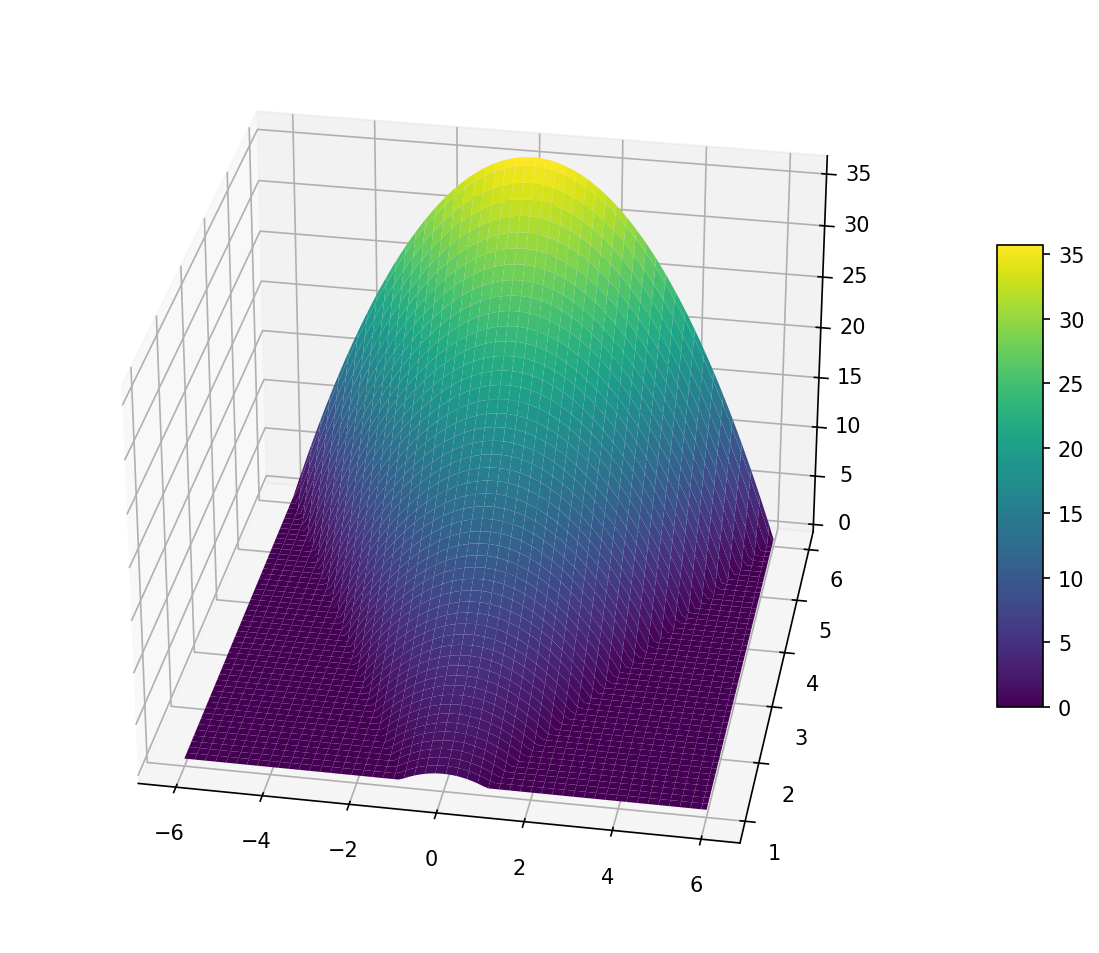

In [ ]:
#Solution_x=0

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-6, 6, 100)      # 원래 코드에서 y 범위 [-1,1]
r_vals = np.linspace(1, 6, 100)     # p 범위 [1.5, 6]

# 2D 그리드 생성 (y,w)
y_grid, r_grid = np.meshgrid(y_vals, r_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_r_plot = torch.tensor(r_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
#sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2)*net_pinn(pt_x_plot, pt_y_plot, pt_r_plot)
sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2)
mask = (pt_x_plot**2 + pt_y_plot**2) < (pt_r_plot**2)
sol_plot = torch.where(mask, sol_plot, torch.zeros_like(sol_plot))

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, r_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.view_init(elev=30, azim=280)
#ax.set_box_aspect([1, 2, 1])

plt.show()


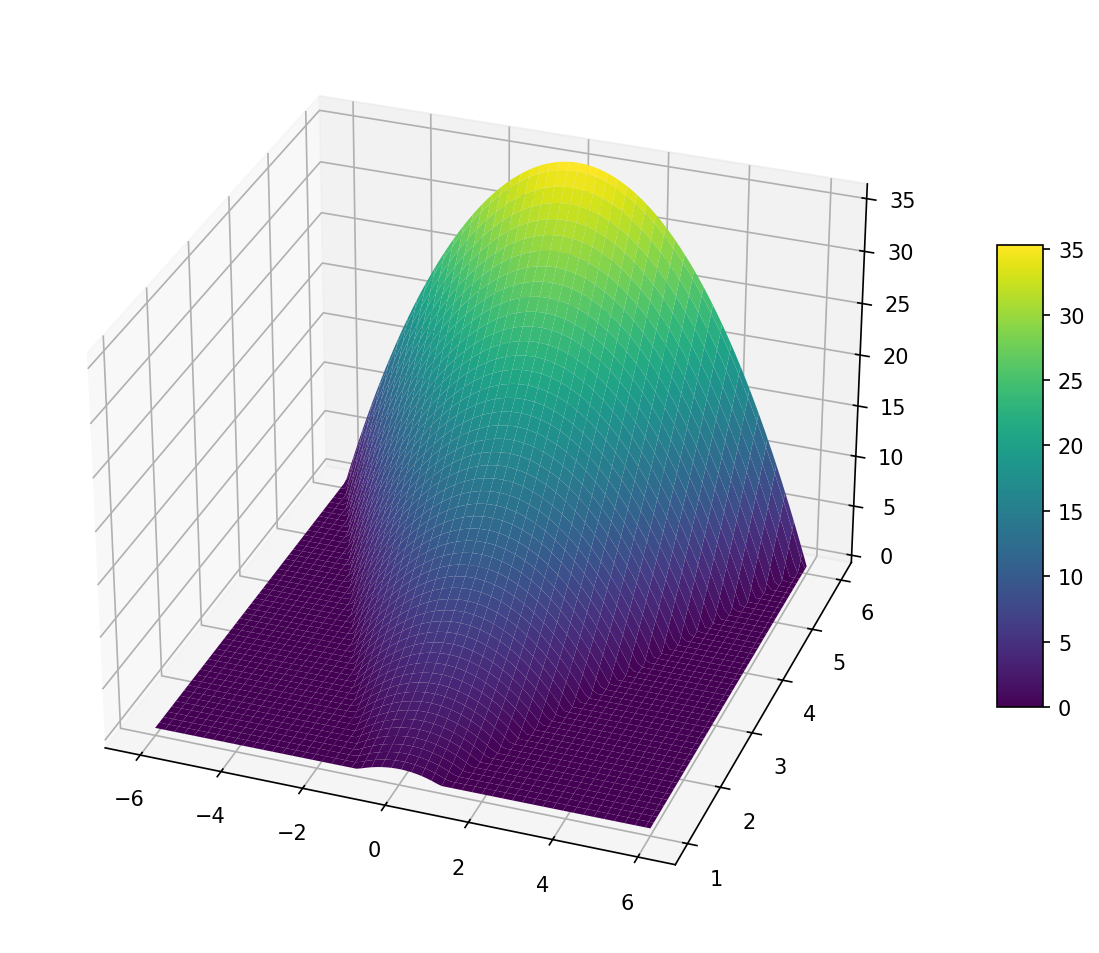

In [ ]:
#Hybrid_x=0

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-6, 6, 100)      # 원래 코드에서 y 범위 [-1,1]
r_vals = np.linspace(1, 6, 100)     # p 범위 [1.5, 6]

# 2D 그리드 생성 (y,w)
y_grid, r_grid = np.meshgrid(y_vals, r_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_r_plot = torch.tensor(r_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2)*net_mix(pt_x_plot, pt_y_plot, pt_r_plot)
#sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2) * (1 - net_mix(pt_x_plot, pt_y_plot, pt_r_plot))
mask = (pt_x_plot**2 + pt_y_plot**2) < (pt_r_plot**2)
sol_plot = torch.where(mask, sol_plot, torch.zeros_like(sol_plot))

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, r_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.view_init(elev=30, azim=290)
#ax.set_box_aspect([1, 2, 1])
#ax.set_zlim(0,1)

plt.show()


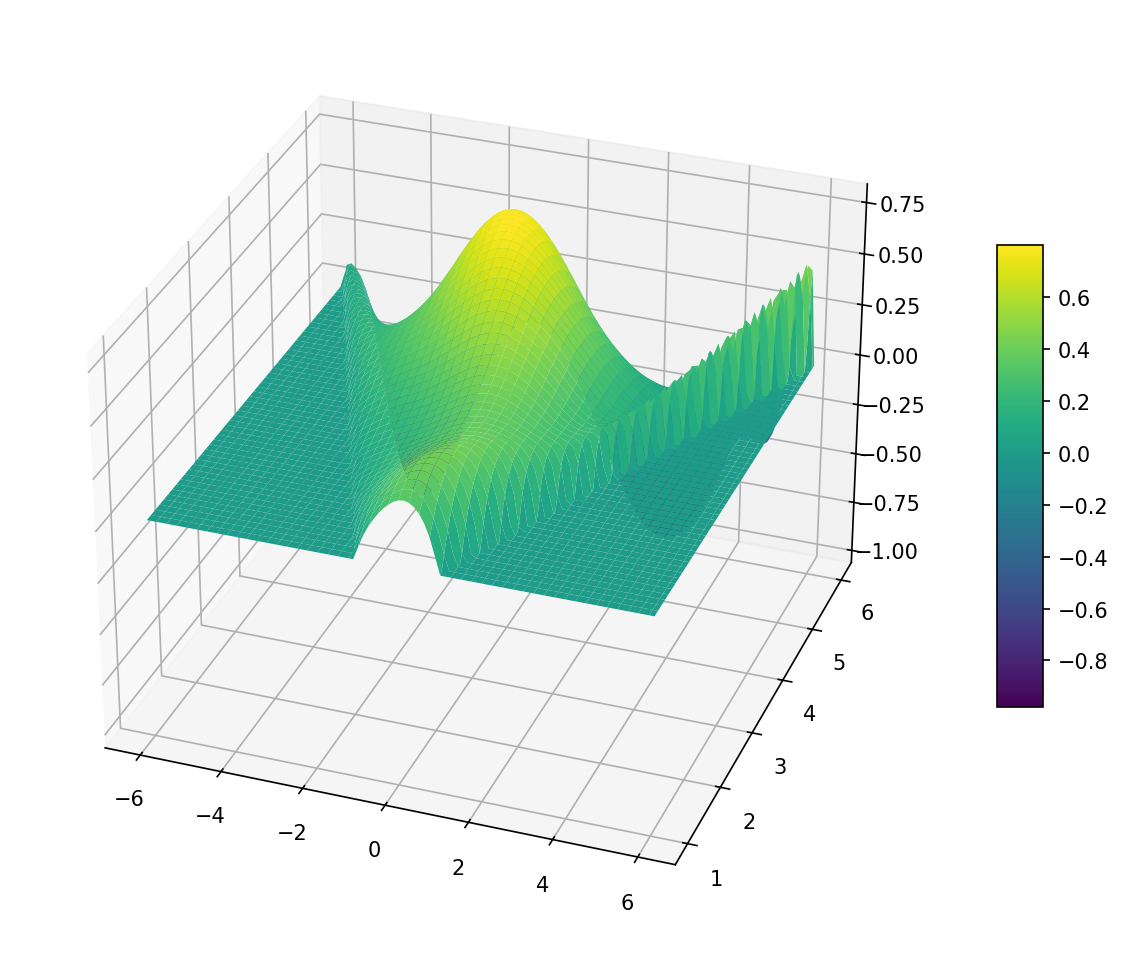

In [ ]:
#DRM_x=0

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-6, 6, 100)      # 원래 코드에서 y 범위 [-1,1]
r_vals = np.linspace(1, 6, 100)     # p 범위 [1.5, 6]

# 2D 그리드 생성 (y,w)
y_grid, r_grid = np.meshgrid(y_vals, r_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_r_plot = torch.tensor(r_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
#sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2)*net_drm(pt_x_plot, pt_y_plot, pt_r_plot)
sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2) * (1 - net_drm(pt_x_plot, pt_y_plot, pt_r_plot))
mask = (pt_x_plot**2 + pt_y_plot**2) < (pt_r_plot**2)
sol_plot = torch.where(mask, sol_plot, torch.zeros_like(sol_plot))

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, r_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.view_init(elev=30, azim=290)
#ax.set_box_aspect([1, 2, 1])
#ax.set_zlim(0,1)

plt.show()


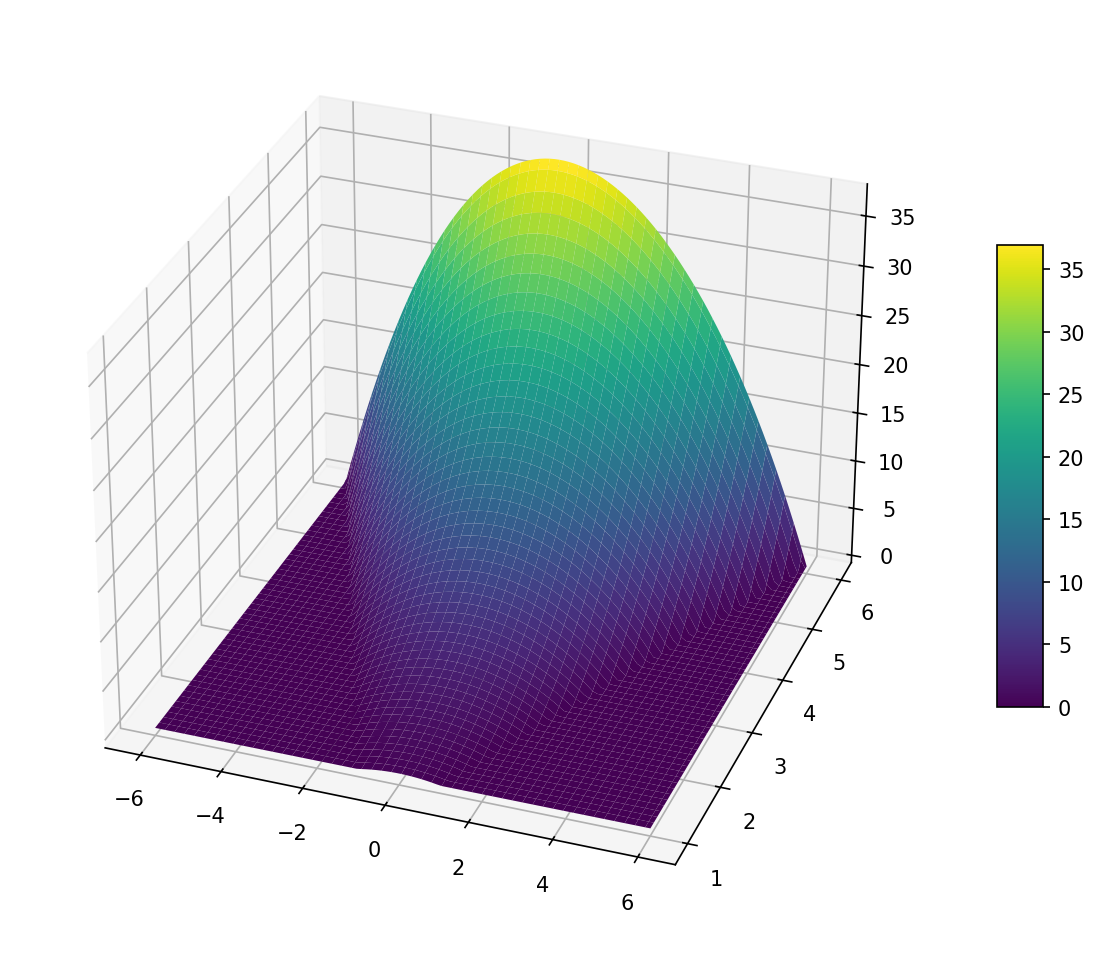

In [ ]:
#PINN_x=0

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-6, 6, 100)      # 원래 코드에서 y 범위 [-1,1]
r_vals = np.linspace(1, 6, 100)     # p 범위 [1.5, 6]

# 2D 그리드 생성 (y,w)
y_grid, r_grid = np.meshgrid(y_vals, r_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_r_plot = torch.tensor(r_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2)*net_pinn(pt_x_plot, pt_y_plot, pt_r_plot)
#sol_plot = (pt_r_plot**2 - pt_x_plot**2 - pt_y_plot**2) * (1 - net_pinn(pt_x_plot, pt_y_plot, pt_r_plot))
mask = (pt_x_plot**2 + pt_y_plot**2) < (pt_r_plot**2)
sol_plot = torch.where(mask, sol_plot, torch.zeros_like(sol_plot))

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, r_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.view_init(elev=30, azim=290)
#ax.set_box_aspect([1, 2, 1])

plt.show()
